# Two-Arm Bandit Analysis: QCARE vs Recency-QCARE

## Overview
- **Data**: Two experiments (Exp1, Exp2) with groups A and B
- **Models**: 
  - QCARE (Structural): Baseline model using full cumulative history
  - Recency-QCARE: Model with recency bias (exponential weighting)
- **Analysis**: Parameter estimation, synthetic curves, train/test validation, and comparative visualization

In [49]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import minimize, minimize_scalar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'A': '#1f77b4', 'B': '#ff7f0e'}  # Blue for A, Orange for B

print("All libraries imported successfully!")

All libraries imported successfully!


## Core Functions: Model Estimation

In [50]:
def estimate_qcare_alpha(df, experiment_label='Exp1'):
    """Estimate alpha using QCARE (Structural) model - NO recency bias"""
    results = []
    df = df.sort_values(by=['participant_id', 'pull_round_index'])
    
    for participant_id, group in df.groupby('participant_id'):
        pulls = group['pull_arm_index'].values
        rewards = group['pull_reward'].values
        ab_group = group['ab_group'].iloc[0]
        T = len(pulls)
        
        # Pre-compute k(t) - cumulative counts (no decay)
        k = np.zeros((T, 2))
        sum_rewards = np.array([0.0, 0.0])
        k_current = np.array([0, 0])
        
        for t in range(T):
            k[t] = k_current.copy()
            k_current[pulls[t]] += 1
            sum_rewards[pulls[t]] += rewards[t]
        
        mean_reward = np.mean(rewards)
        
        def neg_log_likelihood(alpha):
            LL = 0.0
            epsilon = 1e-10
            
            for t in range(T):
                arm = pulls[t]
                other = 1 - arm
                
                if k[t, arm] > 0:
                    mu_arm = sum_rewards[arm] / k[t, arm]
                else:
                    mu_arm = 0.0
                
                if k[t, other] > 0:
                    mu_other = sum_rewards[other] / k[t, other]
                else:
                    mu_other = 0.0
                
                k_arm = k[t, arm]
                k_other = k[t, other]
                
                var_arm = 1.0 / ((k_arm + 1)**(2 * alpha))
                var_other = 1.0 / ((k_other + 1)**(2 * alpha))
                
                std = np.sqrt(var_arm + var_other)
                if std > 0:
                    z = (mu_arm - mu_other) / std
                else:
                    z = 0
                
                prob = norm.cdf(z)
                prob = np.clip(prob, epsilon, 1 - epsilon)
                LL += np.log(prob)
            
            return -LL
        
        res = minimize_scalar(neg_log_likelihood, bounds=(-5.0, 10.0), method='bounded')
        
        results.append({
            'participant_id': participant_id,
            'ab_group': ab_group,
            'alpha': res.x,
            'mean_reward': mean_reward,
            'experiment': experiment_label
        })
    
    return pd.DataFrame(results)

print("QCARE estimation function defined.")

QCARE estimation function defined.


In [51]:
def estimate_recency_qcare(df, experiment_label='Exp1'):
    """Estimate alpha and gamma using Recency-QCARE model"""
    results = []
    df = df.sort_values(by=['participant_id', 'pull_round_index'])
    
    for participant_id, group in df.groupby('participant_id'):
        pulls = group['pull_arm_index'].values
        rewards = group['pull_reward'].values
        ab_group = group['ab_group'].iloc[0]
        T = len(pulls)
        
        # Pre-compute k(t)
        k = np.zeros((T, 2))
        k_current = np.array([0, 0])
        for t in range(T):
            k[t] = k_current.copy()
            k_current[pulls[t]] += 1
        
        mean_reward = np.mean(rewards)
        
        def neg_log_likelihood(params):
            alpha, gamma = params
            
            if gamma <= 0 or gamma >= 1:
                return 1e10
            
            mu_rec = np.zeros(2)
            LL = 0.0
            eps = 1e-10
            
            for t in range(T):
                arm = pulls[t]
                other = 1 - arm
                
                mu_arm = mu_rec[arm]
                mu_other = mu_rec[other]
                
                k_arm = k[t, arm]
                k_other = k[t, other]
                
                var_arm = 1.0 / ((k_arm + 1)**(2 * alpha))
                var_other = 1.0 / ((k_other + 1)**(2 * alpha))
                
                std = np.sqrt(var_arm + var_other)
                if std > 0:
                    z = (mu_arm - mu_other) / std
                else:
                    z = 0
                
                prob = norm.cdf(z)
                prob = np.clip(prob, eps, 1 - eps)
                LL += np.log(prob)
                
                # Update recency-weighted mean
                r = rewards[t]
                mu_rec[arm] = (1 - gamma) * mu_rec[arm] + gamma * r
            
            return -LL
        
        res = minimize(
            neg_log_likelihood,
            x0=[0.5, 0.2],
            bounds=[(-5.0, 10.0), (0.01, 0.99)],
            method='L-BFGS-B'
        )
        
        results.append({
            'participant_id': participant_id,
            'ab_group': ab_group,
            'alpha': res.x[0],
            'gamma': res.x[1],
            'mean_reward': mean_reward,
            'experiment': experiment_label
        })
    
    return pd.DataFrame(results)

print("Recency-QCARE estimation function defined.")

Recency-QCARE estimation function defined.


## Simulation Functions: Synthetic Data Generation

In [52]:
def simulate_qcare_vectorized(T, alphas, mu_config, num_paths=2000):
    """Simulate QCARE model across multiple alpha values"""
    results = {}
    
    for alpha in alphas:
        k = np.zeros((num_paths, 2))
        sum_rewards = np.zeros((num_paths, 2))
        total_rewards = np.zeros(num_paths)
        
        for t in range(T):
            mu_hat = np.zeros((num_paths, 2))
            mask0 = k[:, 0] > 0
            mask1 = k[:, 1] > 0
            mu_hat[mask0, 0] = sum_rewards[mask0, 0] / k[mask0, 0]
            mu_hat[mask1, 1] = sum_rewards[mask1, 1] / k[mask1, 1]
            
            epsilon = np.random.normal(0, 1, size=(2, num_paths))
            beta_0 = 1.0 / ((k[:, 0] + 1) ** alpha)
            beta_1 = 1.0 / ((k[:, 1] + 1) ** alpha)
            
            theta_0 = mu_hat[:, 0] + epsilon[0] * beta_0
            theta_1 = mu_hat[:, 1] + epsilon[1] * beta_1
            
            arm = (theta_1 > theta_0).astype(int)
            
            reward = np.zeros(num_paths)
            reward[arm == 0] = np.random.binomial(1, mu_config[0], size=np.sum(arm == 0))
            reward[arm == 1] = np.random.binomial(1, mu_config[1], size=np.sum(arm == 1))
            
            k[np.arange(num_paths), arm] += 1
            sum_rewards[np.arange(num_paths), arm] += reward
            total_rewards += reward
        
        mean_rewards = total_rewards / T
        results[alpha] = {
            'mean': np.mean(mean_rewards),
            'p5': np.percentile(mean_rewards, 5),
            'p95': np.percentile(mean_rewards, 95)
        }
    
    return results

print("QCARE simulation function defined.")

QCARE simulation function defined.


In [53]:
def simulate_recency_qcare(T, alpha, gamma, mu_config, num_paths=2000):
    """Simulate Recency-QCARE model for specific alpha and gamma"""
    rewards_all = []
    
    for _ in range(num_paths):
        k = np.zeros(2)
        mu_rec = np.zeros(2)
        total_reward = 0
        
        for t in range(T):
            beta = 1.0 / ((k + 1)**alpha)
            epsilon = np.random.normal(0, 1, 2)
            theta = mu_rec + beta * epsilon
            
            arm = np.argmax(theta)
            reward = np.random.binomial(1, mu_config[arm])
            
            # Update recency-weighted mean
            mu_rec[arm] = (1 - gamma) * mu_rec[arm] + gamma * reward
            k[arm] += 1
            total_reward += reward
        
        rewards_all.append(total_reward / T)
    
    return np.array(rewards_all)

print("Recency-QCARE simulation function defined.")

Recency-QCARE simulation function defined.


## Log-Likelihood Functions: Train/Test Validation

In [54]:
def compute_ll_qcare(pulls, rewards, alpha):
    """Compute log-likelihood for QCARE model"""
    T = len(pulls)
    k = np.zeros((T, 2))
    sum_rewards = np.array([0.0, 0.0])
    k_current = np.array([0, 0])
    
    for t in range(T):
        k[t] = k_current.copy()
        k_current[pulls[t]] += 1
        sum_rewards[pulls[t]] += rewards[t]
    
    LL = 0.0
    epsilon = 1e-10
    
    for t in range(T):
        arm = pulls[t]
        other = 1 - arm
        
        mu_arm = sum_rewards[arm] / k[t, arm] if k[t, arm] > 0 else 0.0
        mu_other = sum_rewards[other] / k[t, other] if k[t, other] > 0 else 0.0
        
        var_arm = 1.0 / ((k[t, arm] + 1)**(2 * alpha))
        var_other = 1.0 / ((k[t, other] + 1)**(2 * alpha))
        
        std = np.sqrt(var_arm + var_other)
        z = (mu_arm - mu_other) / std if std > 0 else 0
        
        prob = norm.cdf(z)
        prob = np.clip(prob, epsilon, 1 - epsilon)
        LL += np.log(prob)
    
    return LL

print("QCARE log-likelihood function defined.")

QCARE log-likelihood function defined.


In [55]:
def compute_ll_recency(pulls, rewards, alpha, gamma):
    """Compute log-likelihood for Recency-QCARE model"""
    T = len(pulls)
    k = np.zeros((T, 2))
    k_current = np.array([0, 0])
    
    for t in range(T):
        k[t] = k_current.copy()
        k_current[pulls[t]] += 1
    
    LL = 0.0
    epsilon = 1e-10
    mu_rec = np.zeros(2)
    
    for t in range(T):
        arm = pulls[t]
        other = 1 - arm
        
        mu_arm = mu_rec[arm]
        mu_other = mu_rec[other]
        
        var_arm = 1.0 / ((k[t, arm] + 1)**(2 * alpha))
        var_other = 1.0 / ((k[t, other] + 1)**(2 * alpha))
        
        std = np.sqrt(var_arm + var_other)
        z = (mu_arm - mu_other) / std if std > 0 else 0
        
        prob = norm.cdf(z)
        prob = np.clip(prob, epsilon, 1 - epsilon)
        LL += np.log(prob)
        
        # Update
        mu_rec[arm] = (1 - gamma) * mu_rec[arm] + gamma * rewards[t]
    
    return LL

print("Recency-QCARE log-likelihood function defined.")

Recency-QCARE log-likelihood function defined.


## Data Loading and Preparation

In [56]:
# Load data
script_dir = '/Users/prateekagrawal/Desktop/mini_game_theory/Analysis'
csv_path_exp1 = os.path.join(script_dir, "experiment_exp_1_pull_history (1).csv")
csv_path_exp2 = os.path.join(script_dir, "experiment_exp_2_pull_history (1).csv")

print("Loading experiments...")
df_exp1 = pd.read_csv(csv_path_exp1)
df_exp2 = pd.read_csv(csv_path_exp2)

print(f"Exp1: {len(df_exp1)} rows, {df_exp1['participant_id'].nunique()} participants")
print(f"Exp2: {len(df_exp2)} rows, {df_exp2['participant_id'].nunique()} participants")
print(f"\nGroups in Exp1: {sorted(df_exp1['ab_group'].unique())}")
print(f"Groups in Exp2: {sorted(df_exp2['ab_group'].unique())}")

Loading experiments...
Exp1: 4400 rows, 44 participants
Exp2: 1200 rows, 12 participants

Groups in Exp1: ['A', 'B']
Groups in Exp2: ['A', 'B']


## Step 1: Parameter Estimation for Both Models and Both Experiments

In [57]:
print("="*80)
print("PARAMETER ESTIMATION")
print("="*80)

# Estimate parameters
print("\nEstimating QCARE (Structural) Model...")
qcare_exp1 = estimate_qcare_alpha(df_exp1, 'Exp1')
qcare_exp2 = estimate_qcare_alpha(df_exp2, 'Exp2')
qcare_combined = pd.concat([qcare_exp1, qcare_exp2], ignore_index=True)
print(f"  Exp1: {len(qcare_exp1)} participants")
print(f"  Exp2: {len(qcare_exp2)} participants")

print("\nEstimating Recency-QCARE Model...")
recency_exp1 = estimate_recency_qcare(df_exp1, 'Exp1')
recency_exp2 = estimate_recency_qcare(df_exp2, 'Exp2')
recency_combined = pd.concat([recency_exp1, recency_exp2], ignore_index=True)
print(f"  Exp1: {len(recency_exp1)} participants")
print(f"  Exp2: {len(recency_exp2)} participants")

print("\n" + "="*80)
print("Parameter estimation complete!")

PARAMETER ESTIMATION

Estimating QCARE (Structural) Model...
  Exp1: 44 participants
  Exp2: 12 participants

Estimating Recency-QCARE Model...
  Exp1: 44 participants
  Exp2: 12 participants

Parameter estimation complete!


## QCARE Model: Summary Statistics

In [58]:
print("\n" + "="*80)
print("QCARE MODEL: PARAMETER STATISTICS")
print("="*80)

# Overall statistics
print("\n--- EXPERIMENT 1 ---")
exp1_overall = qcare_exp1.describe()
print(exp1_overall[['alpha', 'mean_reward']])

print("\n--- EXPERIMENT 1 by Group ---")
for grp in sorted(qcare_exp1['ab_group'].unique()):
    subset = qcare_exp1[qcare_exp1['ab_group'] == grp]
    print(f"\nGroup {grp}:")
    print(f"  Participants: {len(subset)}")
    print(f"  Alpha - Mean: {subset['alpha'].mean():.4f}, Std: {subset['alpha'].std():.4f}")
    print(f"  Mean Reward - Mean: {subset['mean_reward'].mean():.4f}, Std: {subset['mean_reward'].std():.4f}")

print("\n" + "-"*80)
print("\n--- EXPERIMENT 2 ---")
exp2_overall = qcare_exp2.describe()
print(exp2_overall[['alpha', 'mean_reward']])

print("\n--- EXPERIMENT 2 by Group ---")
for grp in sorted(qcare_exp2['ab_group'].unique()):
    subset = qcare_exp2[qcare_exp2['ab_group'] == grp]
    print(f"\nGroup {grp}:")
    print(f"  Participants: {len(subset)}")
    print(f"  Alpha - Mean: {subset['alpha'].mean():.4f}, Std: {subset['alpha'].std():.4f}")
    print(f"  Mean Reward - Mean: {subset['mean_reward'].mean():.4f}, Std: {subset['mean_reward'].std():.4f}")

print("\n" + "="*80)


QCARE MODEL: PARAMETER STATISTICS

--- EXPERIMENT 1 ---
           alpha  mean_reward
count  44.000000    44.000000
mean   -2.589782     0.535000
std     2.477960     0.050647
min    -4.999996     0.420000
25%    -4.952096     0.510000
50%    -2.630690     0.530000
75%    -1.297008     0.570000
max     5.914602     0.640000

--- EXPERIMENT 1 by Group ---

Group A:
  Participants: 24
  Alpha - Mean: -2.4165, Std: 2.2855
  Mean Reward - Mean: 0.5304, Std: 0.0484

Group B:
  Participants: 20
  Alpha - Mean: -2.7977, Std: 2.7368
  Mean Reward - Mean: 0.5405, Std: 0.0539

--------------------------------------------------------------------------------

--- EXPERIMENT 2 ---
           alpha  mean_reward
count  12.000000    12.000000
mean   -2.685679     0.453333
std     2.258600     0.028391
min    -4.999995     0.400000
25%    -4.999994     0.437500
50%    -2.682606     0.450000
75%    -0.579369     0.475000
max     0.405455     0.490000

--- EXPERIMENT 2 by Group ---

Group A:
  Participa

## QCARE Model: Train/Test Log-Likelihood Analysis

In [59]:
def compute_train_test_ll(df, params_df, model_type='qcare'):
    """Compute train/test split log-likelihoods"""
    results = []
    
    for participant_id in df['participant_id'].unique():
        participant_data = df[df['participant_id'] == participant_id].sort_values('pull_round_index')
        
        n_rounds = len(participant_data)
        split_idx = int(n_rounds * 0.75)
        
        train_data = participant_data.iloc[:split_idx]
        test_data = participant_data.iloc[split_idx:]
        
        train_pulls = train_data['pull_arm_index'].values
        train_rewards = train_data['pull_reward'].values
        test_pulls = test_data['pull_arm_index'].values
        test_rewards = test_data['pull_reward'].values
        ab_group = participant_data['ab_group'].iloc[0]
        
        # Get estimated parameters
        param_row = params_df[params_df['participant_id'] == participant_id]
        if len(param_row) == 0:
            continue
        
        if model_type == 'qcare':
            alpha = param_row['alpha'].values[0]
            train_ll = compute_ll_qcare(train_pulls, train_rewards, alpha)
            test_ll = compute_ll_qcare(test_pulls, test_rewards, alpha)
        else:  # recency
            alpha = param_row['alpha'].values[0]
            gamma = param_row['gamma'].values[0]
            train_ll = compute_ll_recency(train_pulls, train_rewards, alpha, gamma)
            test_ll = compute_ll_recency(test_pulls, test_rewards, alpha, gamma)
        
        results.append({
            'participant_id': participant_id,
            'ab_group': ab_group,
            'n_train': len(train_data),
            'n_test': len(test_data),
            'train_ll': train_ll,
            'test_ll': test_ll,
            'train_ll_per_round': train_ll / len(train_data) if len(train_data) > 0 else 0,
            'test_ll_per_round': test_ll / len(test_data) if len(test_data) > 0 else 0
        })
    
    return pd.DataFrame(results)

# Compute for QCARE
print("Computing train/test LL for QCARE...")
qcare_traintest_exp1 = compute_train_test_ll(df_exp1, qcare_exp1, model_type='qcare')
qcare_traintest_exp2 = compute_train_test_ll(df_exp2, qcare_exp2, model_type='qcare')

print("\n" + "="*80)
print("QCARE MODEL: TRAIN/TEST LOG-LIKELIHOOD")
print("="*80)

print("\n--- EXPERIMENT 1 ---")
print(f"Mean Train LL: {qcare_traintest_exp1['train_ll'].mean():.4f}")
print(f"Mean Test LL:  {qcare_traintest_exp1['test_ll'].mean():.4f}")
print(f"Mean Train LL/round: {qcare_traintest_exp1['train_ll_per_round'].mean():.4f}")
print(f"Mean Test LL/round:  {qcare_traintest_exp1['test_ll_per_round'].mean():.4f}")
print(f"Overfitting Gap (Train - Test)/round: {(qcare_traintest_exp1['train_ll_per_round'] - qcare_traintest_exp1['test_ll_per_round']).mean():.4f}")

print("\nBy Group:")
for grp in sorted(qcare_traintest_exp1['ab_group'].unique()):
    subset = qcare_traintest_exp1[qcare_traintest_exp1['ab_group'] == grp]
    print(f"\n  Group {grp}:")
    print(f"    Test LL/round - Mean: {subset['test_ll_per_round'].mean():.4f}, Std: {subset['test_ll_per_round'].std():.4f}")

print("\n--- EXPERIMENT 2 ---")
print(f"Mean Train LL: {qcare_traintest_exp2['train_ll'].mean():.4f}")
print(f"Mean Test LL:  {qcare_traintest_exp2['test_ll'].mean():.4f}")
print(f"Mean Train LL/round: {qcare_traintest_exp2['train_ll_per_round'].mean():.4f}")
print(f"Mean Test LL/round:  {qcare_traintest_exp2['test_ll_per_round'].mean():.4f}")
print(f"Overfitting Gap (Train - Test)/round: {(qcare_traintest_exp2['train_ll_per_round'] - qcare_traintest_exp2['test_ll_per_round']).mean():.4f}")

print("\nBy Group:")
for grp in sorted(qcare_traintest_exp2['ab_group'].unique()):
    subset = qcare_traintest_exp2[qcare_traintest_exp2['ab_group'] == grp]
    print(f"\n  Group {grp}:")
    print(f"    Test LL/round - Mean: {subset['test_ll_per_round'].mean():.4f}, Std: {subset['test_ll_per_round'].std():.4f}")

print("\n" + "="*80)

Computing train/test LL for QCARE...

QCARE MODEL: TRAIN/TEST LOG-LIKELIHOOD

--- EXPERIMENT 1 ---
Mean Train LL: -49.8015
Mean Test LL:  -16.5840
Mean Train LL/round: -0.6640
Mean Test LL/round:  -0.6634
Overfitting Gap (Train - Test)/round: -0.0007

By Group:

  Group A:
    Test LL/round - Mean: -0.6455, Std: 0.1550

  Group B:
    Test LL/round - Mean: -0.6848, Std: 0.2202

--- EXPERIMENT 2 ---
Mean Train LL: -48.3674
Mean Test LL:  -18.2926
Mean Train LL/round: -0.6449
Mean Test LL/round:  -0.7317
Overfitting Gap (Train - Test)/round: 0.0868

By Group:

  Group A:
    Test LL/round - Mean: -0.6755, Std: 0.0575

  Group B:
    Test LL/round - Mean: -0.7718, Std: 0.1685



## QCARE Model: Visualization (Alpha vs Mean Reward with Synthetic Curves)

In [60]:
# Estimate reward distributions from data
# For synthetic curves, we estimate mu_0 and mu_1 from each experiment

def estimate_mu_config(df):
    """Estimate reward probabilities for arms"""
    mu_0 = df[df['pull_arm_index'] == 0]['pull_reward'].mean()
    mu_1 = df[df['pull_arm_index'] == 1]['pull_reward'].mean()
    return (mu_0, mu_1)

mu_exp1 = estimate_mu_config(df_exp1)
mu_exp2 = estimate_mu_config(df_exp2)

print(f"Estimated reward rates - Exp1: Arm0={mu_exp1[0]:.3f}, Arm1={mu_exp1[1]:.3f}")
print(f"Estimated reward rates - Exp2: Arm0={mu_exp2[0]:.3f}, Arm1={mu_exp2[1]:.3f}")

# Get trial lengths
n_rounds_exp1 = df_exp1.groupby('participant_id')['pull_round_index'].max().iloc[0] + 1
n_rounds_exp2 = df_exp2.groupby('participant_id')['pull_round_index'].max().iloc[0] + 1

print(f"\nNumber of rounds - Exp1: {n_rounds_exp1}, Exp2: {n_rounds_exp2}")

Estimated reward rates - Exp1: Arm0=0.604, Arm1=0.400
Estimated reward rates - Exp2: Arm0=0.399, Arm1=0.503

Number of rounds - Exp1: 100, Exp2: 100


In [61]:
# Generate synthetic curves
print("Generating synthetic QCARE curves...")
alpha_grid = np.linspace(-2, 3, 40)

print("  Exp1... (this may take ~30-60 seconds)")
sim_results_exp1 = simulate_qcare_vectorized(n_rounds_exp1, alpha_grid, mu_exp1, num_paths=2000)

print("  Exp2... (this may take ~30-60 seconds)")
sim_results_exp2 = simulate_qcare_vectorized(n_rounds_exp2, alpha_grid, mu_exp2, num_paths=2000)

# Extract curves
mean_curve_exp1 = np.array([sim_results_exp1[a]['mean'] for a in alpha_grid])
p5_curve_exp1 = np.array([sim_results_exp1[a]['p5'] for a in alpha_grid])
p95_curve_exp1 = np.array([sim_results_exp1[a]['p95'] for a in alpha_grid])
opt_alpha_exp1 = alpha_grid[np.argmax(mean_curve_exp1)]

mean_curve_exp2 = np.array([sim_results_exp2[a]['mean'] for a in alpha_grid])
p5_curve_exp2 = np.array([sim_results_exp2[a]['p5'] for a in alpha_grid])
p95_curve_exp2 = np.array([sim_results_exp2[a]['p95'] for a in alpha_grid])
opt_alpha_exp2 = alpha_grid[np.argmax(mean_curve_exp2)]

print(f"\nOptimal alpha - Exp1: {opt_alpha_exp1:.3f}")
print(f"Optimal alpha - Exp2: {opt_alpha_exp2:.3f}")

Generating synthetic QCARE curves...
  Exp1... (this may take ~30-60 seconds)
  Exp2... (this may take ~30-60 seconds)

Optimal alpha - Exp1: 1.077
Optimal alpha - Exp2: 0.949



Saved: QCARE_Alpha_vs_Reward_Both_Exp.png


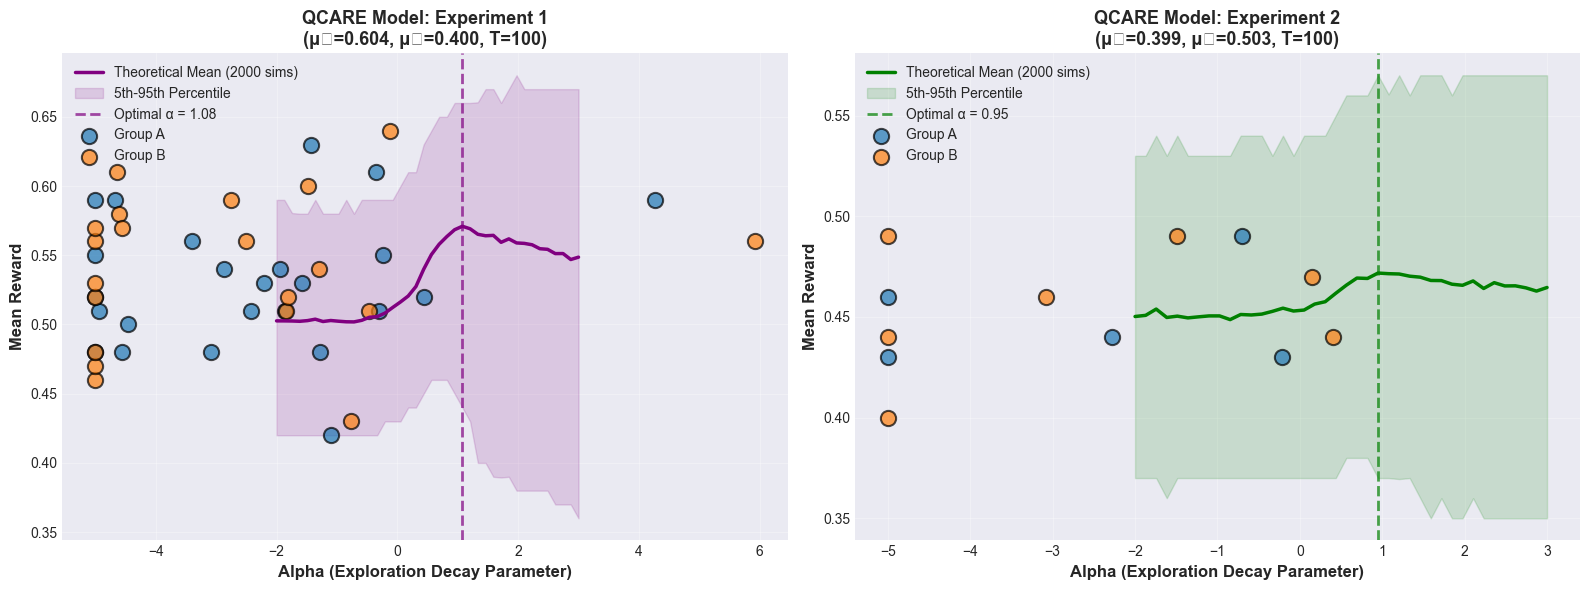

In [62]:
# Create figure with 2 subplots (Exp1 and Exp2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- EXPERIMENT 1 ---
ax = axes[0]

# Plot theoretical curves
ax.plot(alpha_grid, mean_curve_exp1, color='purple', linewidth=2.5, label='Theoretical Mean (2000 sims)', zorder=3)
ax.fill_between(alpha_grid, p5_curve_exp1, p95_curve_exp1, color='purple', alpha=0.15, label='5th-95th Percentile')
ax.axvline(x=opt_alpha_exp1, color='purple', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal α = {opt_alpha_exp1:.2f}')

# Plot participant data
for grp in sorted(qcare_exp1['ab_group'].unique()):
    subset = qcare_exp1[qcare_exp1['ab_group'] == grp]
    ax.scatter(subset['alpha'], subset['mean_reward'], s=120, alpha=0.7, 
               color=colors[grp], label=f'Group {grp}', edgecolors='black', linewidth=1.5, zorder=2)

ax.set_xlabel('Alpha (Exploration Decay Parameter)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title(f'QCARE Model: Experiment 1\n(μ₀={mu_exp1[0]:.3f}, μ₁={mu_exp1[1]:.3f}, T={n_rounds_exp1})', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# --- EXPERIMENT 2 ---
ax = axes[1]

# Plot theoretical curves
ax.plot(alpha_grid, mean_curve_exp2, color='green', linewidth=2.5, label='Theoretical Mean (2000 sims)', zorder=3)
ax.fill_between(alpha_grid, p5_curve_exp2, p95_curve_exp2, color='green', alpha=0.15, label='5th-95th Percentile')
ax.axvline(x=opt_alpha_exp2, color='green', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal α = {opt_alpha_exp2:.2f}')

# Plot participant data
for grp in sorted(qcare_exp2['ab_group'].unique()):
    subset = qcare_exp2[qcare_exp2['ab_group'] == grp]
    ax.scatter(subset['alpha'], subset['mean_reward'], s=120, alpha=0.7, 
              color=colors[grp], label=f'Group {grp}', edgecolors='black', linewidth=1.5, zorder=2)

ax.set_xlabel('Alpha (Exploration Decay Parameter)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title(f'QCARE Model: Experiment 2\n(μ₀={mu_exp2[0]:.3f}, μ₁={mu_exp2[1]:.3f}, T={n_rounds_exp2})', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(script_dir, 'QCARE_Alpha_vs_Reward_Both_Exp.png'), dpi=300, bbox_inches='tight')
print("\nSaved: QCARE_Alpha_vs_Reward_Both_Exp.png")
plt.show()

## Recency-QCARE Model: Summary Statistics

In [63]:
print("\n" + "="*80)
print("RECENCY-QCARE MODEL: PARAMETER STATISTICS")
print("="*80)

print("\n--- EXPERIMENT 1 ---")
print(recency_exp1[['alpha', 'gamma', 'mean_reward']].describe())

print("\n--- EXPERIMENT 1 by Group ---")
for grp in sorted(recency_exp1['ab_group'].unique()):
    subset = recency_exp1[recency_exp1['ab_group'] == grp]
    print(f"\nGroup {grp}:")
    print(f"  Participants: {len(subset)}")
    print(f"  Alpha - Mean: {subset['alpha'].mean():.4f}, Std: {subset['alpha'].std():.4f}")
    print(f"  Gamma - Mean: {subset['gamma'].mean():.4f}, Std: {subset['gamma'].std():.4f}")
    print(f"  Mean Reward - Mean: {subset['mean_reward'].mean():.4f}, Std: {subset['mean_reward'].std():.4f}")

print("\n" + "-"*80)
print("\n--- EXPERIMENT 2 ---")
print(recency_exp2[['alpha', 'gamma', 'mean_reward']].describe())

print("\n--- EXPERIMENT 2 by Group ---")
for grp in sorted(recency_exp2['ab_group'].unique()):
    subset = recency_exp2[recency_exp2['ab_group'] == grp]
    print(f"\nGroup {grp}:")
    print(f"  Participants: {len(subset)}")
    print(f"  Alpha - Mean: {subset['alpha'].mean():.4f}, Std: {subset['alpha'].std():.4f}")
    print(f"  Gamma - Mean: {subset['gamma'].mean():.4f}, Std: {subset['gamma'].std():.4f}")
    print(f"  Mean Reward - Mean: {subset['mean_reward'].mean():.4f}, Std: {subset['mean_reward'].std():.4f}")

print("\n" + "="*80)


RECENCY-QCARE MODEL: PARAMETER STATISTICS

--- EXPERIMENT 1 ---
           alpha      gamma  mean_reward
count  44.000000  44.000000    44.000000
mean    0.269027   0.598430     0.535000
std     2.706090   0.405802     0.050647
min    -5.000000   0.010000     0.420000
25%    -0.112944   0.196699     0.510000
50%     0.386398   0.738207     0.530000
75%     0.698176   0.990000     0.570000
max    10.000000   0.990000     0.640000

--- EXPERIMENT 1 by Group ---

Group A:
  Participants: 24
  Alpha - Mean: 0.3291, Std: 2.6108
  Gamma - Mean: 0.5888, Std: 0.4188
  Mean Reward - Mean: 0.5304, Std: 0.0484

Group B:
  Participants: 20
  Alpha - Mean: 0.1970, Std: 2.8830
  Gamma - Mean: 0.6099, Std: 0.4001
  Mean Reward - Mean: 0.5405, Std: 0.0539

--------------------------------------------------------------------------------

--- EXPERIMENT 2 ---
           alpha      gamma  mean_reward
count  12.000000  12.000000    12.000000
mean   -0.026147   0.534221     0.453333
std     1.652006   0.4

## Recency-QCARE Model: Train/Test Log-Likelihood Analysis

In [64]:
# Compute for Recency-QCARE
print("Computing train/test LL for Recency-QCARE...")
recency_traintest_exp1 = compute_train_test_ll(df_exp1, recency_exp1, model_type='recency')
recency_traintest_exp2 = compute_train_test_ll(df_exp2, recency_exp2, model_type='recency')

print("\n" + "="*80)
print("RECENCY-QCARE MODEL: TRAIN/TEST LOG-LIKELIHOOD")
print("="*80)

print("\n--- EXPERIMENT 1 ---")
print(f"Mean Train LL: {recency_traintest_exp1['train_ll'].mean():.4f}")
print(f"Mean Test LL:  {recency_traintest_exp1['test_ll'].mean():.4f}")
print(f"Mean Train LL/round: {recency_traintest_exp1['train_ll_per_round'].mean():.4f}")
print(f"Mean Test LL/round:  {recency_traintest_exp1['test_ll_per_round'].mean():.4f}")
print(f"Overfitting Gap (Train - Test)/round: {(recency_traintest_exp1['train_ll_per_round'] - recency_traintest_exp1['test_ll_per_round']).mean():.4f}")

print("\nBy Group:")
for grp in sorted(recency_traintest_exp1['ab_group'].unique()):
    subset = recency_traintest_exp1[recency_traintest_exp1['ab_group'] == grp]
    print(f"\n  Group {grp}:")
    print(f"    Test LL/round - Mean: {subset['test_ll_per_round'].mean():.4f}, Std: {subset['test_ll_per_round'].std():.4f}")

print("\n--- EXPERIMENT 2 ---")
print(f"Mean Train LL: {recency_traintest_exp2['train_ll'].mean():.4f}")
print(f"Mean Test LL:  {recency_traintest_exp2['test_ll'].mean():.4f}")
print(f"Mean Train LL/round: {recency_traintest_exp2['train_ll_per_round'].mean():.4f}")
print(f"Mean Test LL/round:  {recency_traintest_exp2['test_ll_per_round'].mean():.4f}")
print(f"Overfitting Gap (Train - Test)/round: {(recency_traintest_exp2['train_ll_per_round'] - recency_traintest_exp2['test_ll_per_round']).mean():.4f}")

print("\nBy Group:")
for grp in sorted(recency_traintest_exp2['ab_group'].unique()):
    subset = recency_traintest_exp2[recency_traintest_exp2['ab_group'] == grp]
    print(f"\n  Group {grp}:")
    print(f"    Test LL/round - Mean: {subset['test_ll_per_round'].mean():.4f}, Std: {subset['test_ll_per_round'].std():.4f}")

print("\n" + "="*80)

# Model comparison
print("\n" + "="*80)
print("MODEL COMPARISON: Test Set LL/round")
print("="*80)
print(f"\nExperiment 1:")
print(f"  QCARE:          {qcare_traintest_exp1['test_ll_per_round'].mean():.4f}")
print(f"  Recency-QCARE:  {recency_traintest_exp1['test_ll_per_round'].mean():.4f}")
print(f"  Improvement:    {(recency_traintest_exp1['test_ll_per_round'].mean() - qcare_traintest_exp1['test_ll_per_round'].mean()):.4f}")

print(f"\nExperiment 2:")
print(f"  QCARE:          {qcare_traintest_exp2['test_ll_per_round'].mean():.4f}")
print(f"  Recency-QCARE:  {recency_traintest_exp2['test_ll_per_round'].mean():.4f}")
print(f"  Improvement:    {(recency_traintest_exp2['test_ll_per_round'].mean() - qcare_traintest_exp2['test_ll_per_round'].mean()):.4f}")
print("="*80)

Computing train/test LL for Recency-QCARE...

RECENCY-QCARE MODEL: TRAIN/TEST LOG-LIKELIHOOD

--- EXPERIMENT 1 ---
Mean Train LL: -38.2275
Mean Test LL:  -13.9354
Mean Train LL/round: -0.5097
Mean Test LL/round:  -0.5574
Overfitting Gap (Train - Test)/round: 0.0477

By Group:

  Group A:
    Test LL/round - Mean: -0.5519, Std: 0.1374

  Group B:
    Test LL/round - Mean: -0.5641, Std: 0.1408

--- EXPERIMENT 2 ---
Mean Train LL: -41.5020
Mean Test LL:  -14.7980
Mean Train LL/round: -0.5534
Mean Test LL/round:  -0.5919
Overfitting Gap (Train - Test)/round: 0.0386

By Group:

  Group A:
    Test LL/round - Mean: -0.6352, Std: 0.1238

  Group B:
    Test LL/round - Mean: -0.5610, Std: 0.1038


MODEL COMPARISON: Test Set LL/round

Experiment 1:
  QCARE:          -0.6634
  Recency-QCARE:  -0.5574
  Improvement:    0.1059

Experiment 2:
  QCARE:          -0.7317
  Recency-QCARE:  -0.5919
  Improvement:    0.1398


## Recency-QCARE Model: Visualization (4 Plots: Alpha & Gamma vs Mean Reward)

Generating synthetic curves for Recency-QCARE...
  Exp1 with mean gamma=0.5984...
  Exp2 with mean gamma=0.5342...
Synthetic curves generated!
Saved: Recency_QCARE_4Panel_Both_Exp.png


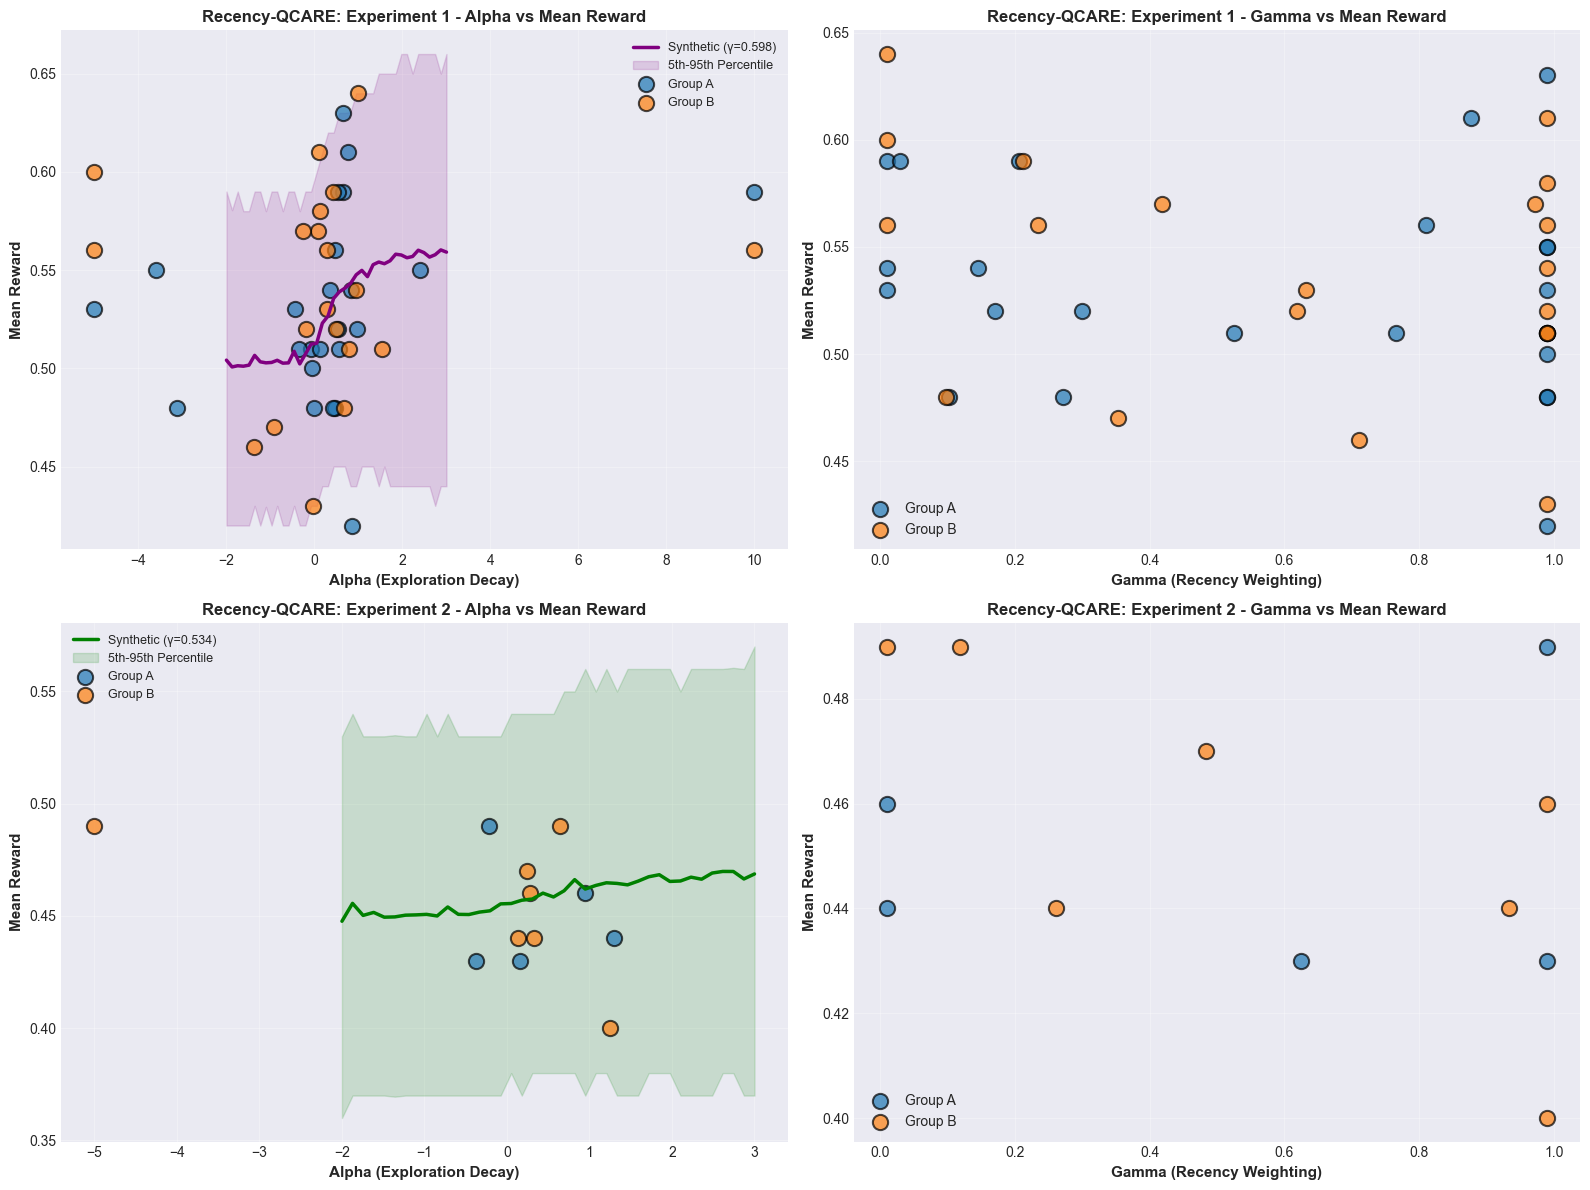

In [65]:
# Create 2x2 grid: (Exp1 Alpha, Exp1 Gamma) and (Exp2 Alpha, Exp2 Gamma)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Generate synthetic curves for Recency-QCARE using mean gammas
print("Generating synthetic curves for Recency-QCARE...")
mean_gamma_exp1 = recency_exp1['gamma'].mean()
mean_gamma_exp2 = recency_exp2['gamma'].mean()

print(f"  Exp1 with mean gamma={mean_gamma_exp1:.4f}...")
sim_results_rec_exp1 = {}
for alpha in alpha_grid:
    rewards = simulate_recency_qcare(n_rounds_exp1, alpha, mean_gamma_exp1, mu_exp1, num_paths=1000)
    sim_results_rec_exp1[alpha] = {
        'mean': np.mean(rewards),
        'p5': np.percentile(rewards, 5),
        'p95': np.percentile(rewards, 95)
    }

print(f"  Exp2 with mean gamma={mean_gamma_exp2:.4f}...")
sim_results_rec_exp2 = {}
for alpha in alpha_grid:
    rewards = simulate_recency_qcare(n_rounds_exp2, alpha, mean_gamma_exp2, mu_exp2, num_paths=1000)
    sim_results_rec_exp2[alpha] = {
        'mean': np.mean(rewards),
        'p5': np.percentile(rewards, 5),
        'p95': np.percentile(rewards, 95)
    }

mean_curve_rec_exp1 = np.array([sim_results_rec_exp1[a]['mean'] for a in alpha_grid])
p5_curve_rec_exp1 = np.array([sim_results_rec_exp1[a]['p5'] for a in alpha_grid])
p95_curve_rec_exp1 = np.array([sim_results_rec_exp1[a]['p95'] for a in alpha_grid])

mean_curve_rec_exp2 = np.array([sim_results_rec_exp2[a]['mean'] for a in alpha_grid])
p5_curve_rec_exp2 = np.array([sim_results_rec_exp2[a]['p5'] for a in alpha_grid])
p95_curve_rec_exp2 = np.array([sim_results_rec_exp2[a]['p95'] for a in alpha_grid])

print("Synthetic curves generated!")

# --- Row 1: EXPERIMENT 1 ---
# Plot 1: Exp1 - Alpha vs Mean Reward (with synthetic curve)
ax = axes[0, 0]

# Plot theoretical curve
ax.plot(alpha_grid, mean_curve_rec_exp1, color='purple', linewidth=2.5, 
        label=f'Synthetic (γ={mean_gamma_exp1:.3f})', zorder=3)
ax.fill_between(alpha_grid, p5_curve_rec_exp1, p95_curve_rec_exp1, 
                color='purple', alpha=0.15, label='5th-95th Percentile')

# Plot participant data
for grp in sorted(recency_exp1['ab_group'].unique()):
    subset = recency_exp1[recency_exp1['ab_group'] == grp]
    ax.scatter(subset['alpha'], subset['mean_reward'], s=120, alpha=0.7,
              color=colors[grp], label=f'Group {grp}', edgecolors='black', linewidth=1.5, zorder=2)

ax.set_xlabel('Alpha (Exploration Decay)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
ax.set_title('Recency-QCARE: Experiment 1 - Alpha vs Mean Reward', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Exp1 - Gamma vs Mean Reward
ax = axes[0, 1]
for grp in sorted(recency_exp1['ab_group'].unique()):
    subset = recency_exp1[recency_exp1['ab_group'] == grp]
    ax.scatter(subset['gamma'], subset['mean_reward'], s=120, alpha=0.7,
              color=colors[grp], label=f'Group {grp}', edgecolors='black', linewidth=1.5)

ax.set_xlabel('Gamma (Recency Weighting)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
ax.set_title('Recency-QCARE: Experiment 1 - Gamma vs Mean Reward', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# --- Row 2: EXPERIMENT 2 ---
# Plot 3: Exp2 - Alpha vs Mean Reward (with synthetic curve)
ax = axes[1, 0]

# Plot theoretical curve
ax.plot(alpha_grid, mean_curve_rec_exp2, color='green', linewidth=2.5, 
        label=f'Synthetic (γ={mean_gamma_exp2:.3f})', zorder=3)
ax.fill_between(alpha_grid, p5_curve_rec_exp2, p95_curve_rec_exp2, 
                color='green', alpha=0.15, label='5th-95th Percentile')

# Plot participant data
for grp in sorted(recency_exp2['ab_group'].unique()):
    subset = recency_exp2[recency_exp2['ab_group'] == grp]
    ax.scatter(subset['alpha'], subset['mean_reward'], s=120, alpha=0.7,
              color=colors[grp], label=f'Group {grp}', edgecolors='black', linewidth=1.5, zorder=2)

ax.set_xlabel('Alpha (Exploration Decay)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
ax.set_title('Recency-QCARE: Experiment 2 - Alpha vs Mean Reward', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Exp2 - Gamma vs Mean Reward
ax = axes[1, 1]
for grp in sorted(recency_exp2['ab_group'].unique()):
    subset = recency_exp2[recency_exp2['ab_group'] == grp]
    ax.scatter(subset['gamma'], subset['mean_reward'], s=120, alpha=0.7,
              color=colors[grp], label=f'Group {grp}', edgecolors='black', linewidth=1.5)

ax.set_xlabel('Gamma (Recency Weighting)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
ax.set_title('Recency-QCARE: Experiment 2 - Gamma vs Mean Reward', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(script_dir, 'Recency_QCARE_4Panel_Both_Exp.png'), dpi=300, bbox_inches='tight')
print("Saved: Recency_QCARE_4Panel_Both_Exp.png")
plt.show()


## Alpha Shift Visualization: QCARE → Recency-QCARE (By Group & Experiment)

In [66]:
# Merge QCARE and Recency results for each experiment
exp1_merged = qcare_exp1[['participant_id', 'ab_group', 'alpha', 'mean_reward']].copy()
exp1_merged.rename(columns={'alpha': 'alpha_qcare'}, inplace=True)
exp1_merged = exp1_merged.merge(
    recency_exp1[['participant_id', 'alpha', 'gamma']],
    on='participant_id',
    how='inner'
)
exp1_merged.rename(columns={'alpha': 'alpha_recency'}, inplace=True)

exp2_merged = qcare_exp2[['participant_id', 'ab_group', 'alpha', 'mean_reward']].copy()
exp2_merged.rename(columns={'alpha': 'alpha_qcare'}, inplace=True)
exp2_merged = exp2_merged.merge(
    recency_exp2[['participant_id', 'alpha', 'gamma']],
    on='participant_id',
    how='inner'
)
exp2_merged.rename(columns={'alpha': 'alpha_recency'}, inplace=True)

print(f"Exp1 merged: {len(exp1_merged)} participants")
print(f"Exp2 merged: {len(exp2_merged)} participants")

Exp1 merged: 44 participants
Exp2 merged: 12 participants


Saved: Alpha_Shift_Exp1_By_Group.png


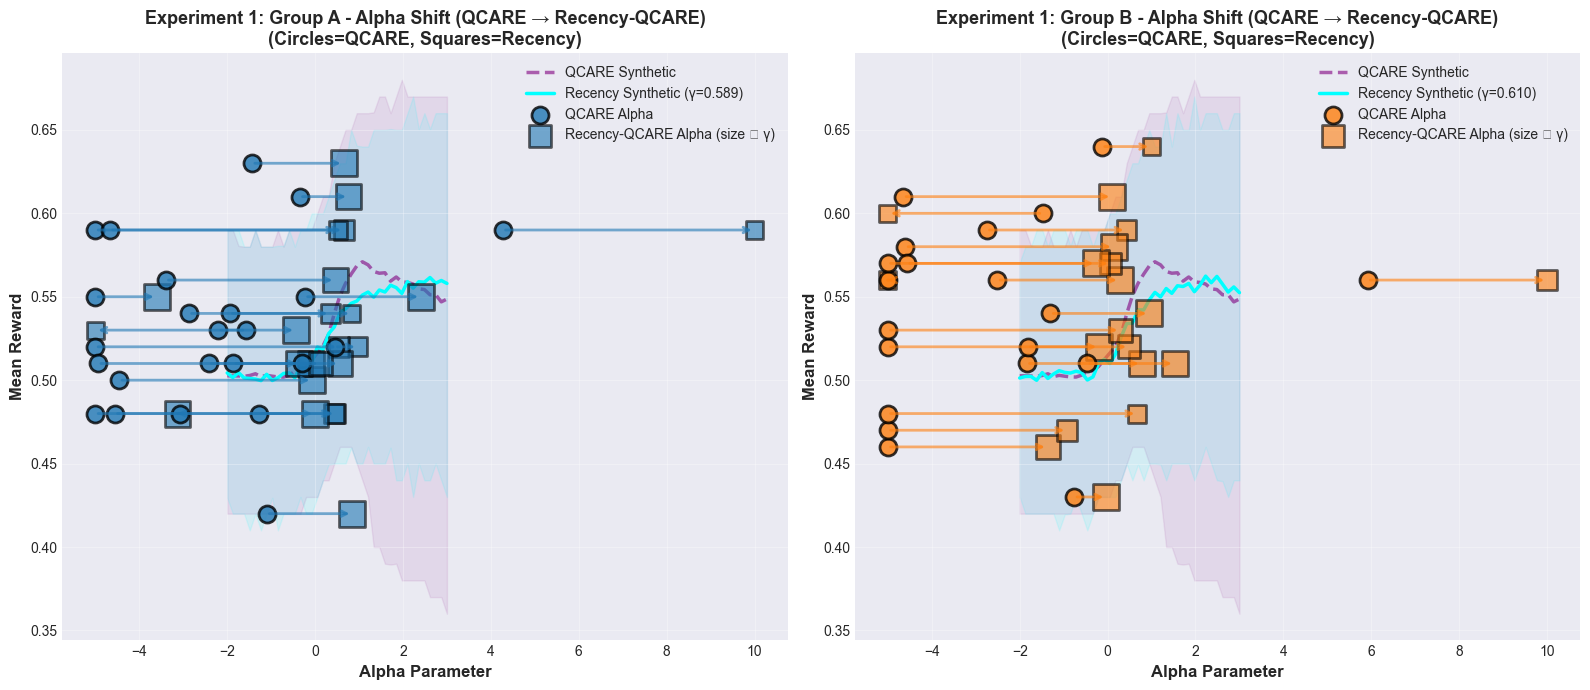

In [67]:
# Create separate plots for Exp1: Group A and Group B
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- EXPERIMENT 1: GROUP A ---
ax = axes[0]
group_a_data = exp1_merged[exp1_merged['ab_group'] == 'A']

# Plot QCARE synthetic curve
ax.plot(alpha_grid, mean_curve_exp1, color='purple', linewidth=2.5, 
        label='QCARE Synthetic', zorder=1, alpha=0.6, linestyle='--')
ax.fill_between(alpha_grid, p5_curve_exp1, p95_curve_exp1, 
                color='purple', alpha=0.08, zorder=0)

# Plot Recency-QCARE synthetic curve for mean gamma
mean_gamma_a = group_a_data['gamma'].mean()
syn_rec_a = {}
for alpha in alpha_grid:
    rewards = simulate_recency_qcare(n_rounds_exp1, alpha, mean_gamma_a, mu_exp1, num_paths=500)
    syn_rec_a[alpha] = {
        'mean': np.mean(rewards),
        'p5': np.percentile(rewards, 5),
        'p95': np.percentile(rewards, 95)
    }
mean_curve_rec_a = np.array([syn_rec_a[a]['mean'] for a in alpha_grid])
p5_curve_rec_a = np.array([syn_rec_a[a]['p5'] for a in alpha_grid])
p95_curve_rec_a = np.array([syn_rec_a[a]['p95'] for a in alpha_grid])

ax.plot(alpha_grid, mean_curve_rec_a, color='cyan', linewidth=2.5, 
        label=f'Recency Synthetic (γ={mean_gamma_a:.3f})', zorder=1)
ax.fill_between(alpha_grid, p5_curve_rec_a, p95_curve_rec_a, 
                color='cyan', alpha=0.1, zorder=0)

# Plot QCARE (circles)
ax.scatter(group_a_data['alpha_qcare'], group_a_data['mean_reward'], 
          s=150, color=colors['A'], marker='o', alpha=0.8, 
          label='QCARE Alpha', edgecolors='black', linewidth=2, zorder=3)

# Plot Recency-QCARE (squares) with size proportional to gamma
sizes = 150 + (group_a_data['gamma'] * 200)
ax.scatter(group_a_data['alpha_recency'], group_a_data['mean_reward'], 
          s=sizes, color=colors['A'], marker='s', alpha=0.6, 
          label='Recency-QCARE Alpha (size ∝ γ)', edgecolors='black', linewidth=2, zorder=2)

# Draw arrows from QCARE to Recency-QCARE
for idx, row in group_a_data.iterrows():
    ax.annotate('', xy=(row['alpha_recency'], row['mean_reward']), 
               xytext=(row['alpha_qcare'], row['mean_reward']),
               arrowprops=dict(arrowstyle='->', lw=2, color=colors['A'], alpha=0.6))

ax.set_xlabel('Alpha Parameter', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title('Experiment 1: Group A - Alpha Shift (QCARE → Recency-QCARE)\n(Circles=QCARE, Squares=Recency)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# --- EXPERIMENT 1: GROUP B ---
ax = axes[1]
group_b_data = exp1_merged[exp1_merged['ab_group'] == 'B']

# Plot QCARE synthetic curve
ax.plot(alpha_grid, mean_curve_exp1, color='purple', linewidth=2.5, 
        label='QCARE Synthetic', zorder=1, alpha=0.6, linestyle='--')
ax.fill_between(alpha_grid, p5_curve_exp1, p95_curve_exp1, 
                color='purple', alpha=0.08, zorder=0)

# Plot Recency-QCARE synthetic curve for mean gamma
mean_gamma_b = group_b_data['gamma'].mean()
syn_rec_b = {}
for alpha in alpha_grid:
    rewards = simulate_recency_qcare(n_rounds_exp1, alpha, mean_gamma_b, mu_exp1, num_paths=500)
    syn_rec_b[alpha] = {
        'mean': np.mean(rewards),
        'p5': np.percentile(rewards, 5),
        'p95': np.percentile(rewards, 95)
    }
mean_curve_rec_b = np.array([syn_rec_b[a]['mean'] for a in alpha_grid])
p5_curve_rec_b = np.array([syn_rec_b[a]['p5'] for a in alpha_grid])
p95_curve_rec_b = np.array([syn_rec_b[a]['p95'] for a in alpha_grid])

ax.plot(alpha_grid, mean_curve_rec_b, color='cyan', linewidth=2.5, 
        label=f'Recency Synthetic (γ={mean_gamma_b:.3f})', zorder=1)
ax.fill_between(alpha_grid, p5_curve_rec_b, p95_curve_rec_b, 
                color='cyan', alpha=0.1, zorder=0)

# Plot QCARE (circles)
ax.scatter(group_b_data['alpha_qcare'], group_b_data['mean_reward'], 
          s=150, color=colors['B'], marker='o', alpha=0.8, 
          label='QCARE Alpha', edgecolors='black', linewidth=2, zorder=3)

# Plot Recency-QCARE (squares) with size proportional to gamma
sizes = 150 + (group_b_data['gamma'] * 200)
ax.scatter(group_b_data['alpha_recency'], group_b_data['mean_reward'], 
          s=sizes, color=colors['B'], marker='s', alpha=0.6, 
          label='Recency-QCARE Alpha (size ∝ γ)', edgecolors='black', linewidth=2, zorder=2)

# Draw arrows from QCARE to Recency-QCARE
for idx, row in group_b_data.iterrows():
    ax.annotate('', xy=(row['alpha_recency'], row['mean_reward']), 
               xytext=(row['alpha_qcare'], row['mean_reward']),
               arrowprops=dict(arrowstyle='->', lw=2, color=colors['B'], alpha=0.6))

ax.set_xlabel('Alpha Parameter', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title('Experiment 1: Group B - Alpha Shift (QCARE → Recency-QCARE)\n(Circles=QCARE, Squares=Recency)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(script_dir, 'Alpha_Shift_Exp1_By_Group.png'), dpi=300, bbox_inches='tight')
print("Saved: Alpha_Shift_Exp1_By_Group.png")
plt.show()


Saved: Alpha_Shift_Exp2_By_Group.png


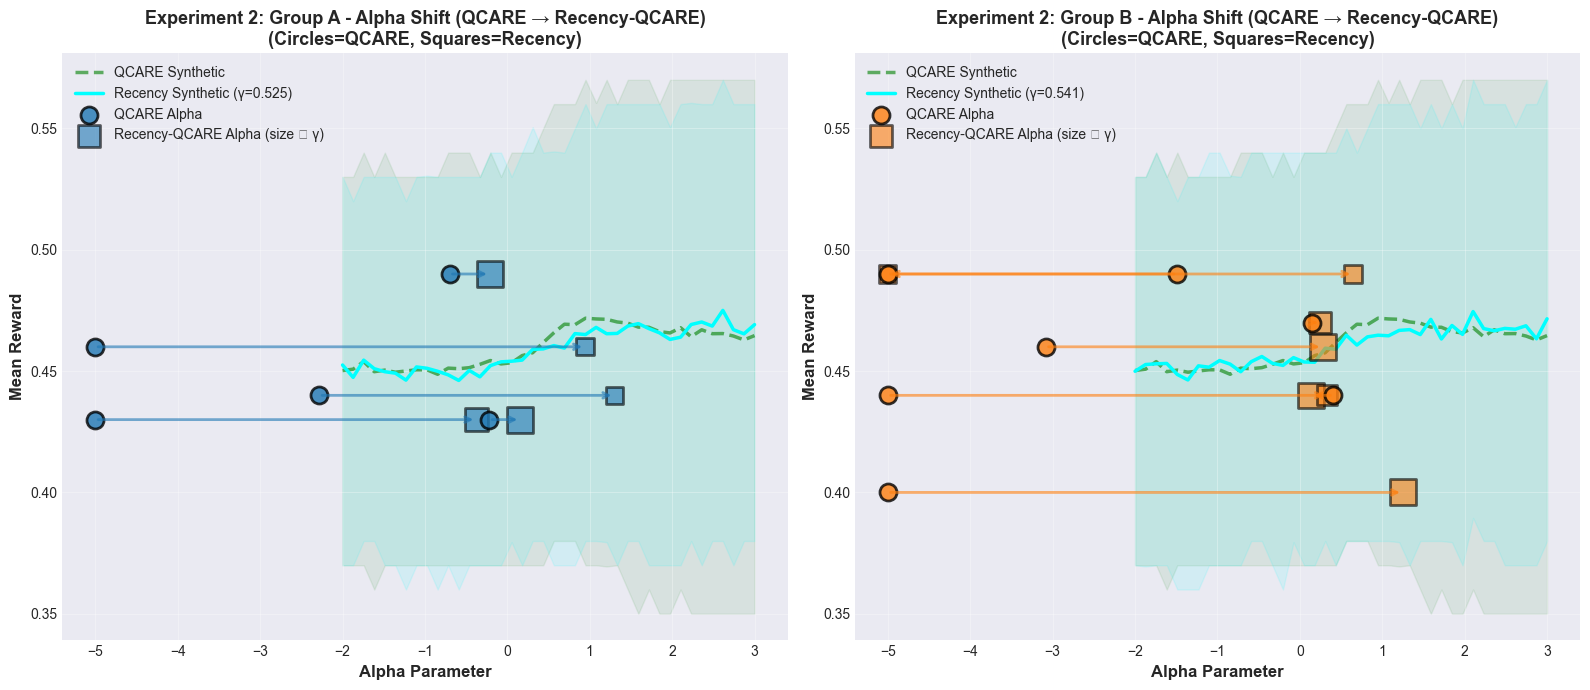

In [68]:
# Create separate plots for Exp2: Group A and Group B
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- EXPERIMENT 2: GROUP A ---
ax = axes[0]
group_a_data = exp2_merged[exp2_merged['ab_group'] == 'A']

# Plot QCARE synthetic curve
ax.plot(alpha_grid, mean_curve_exp2, color='green', linewidth=2.5, 
        label='QCARE Synthetic', zorder=1, alpha=0.6, linestyle='--')
ax.fill_between(alpha_grid, p5_curve_exp2, p95_curve_exp2, 
                color='green', alpha=0.08, zorder=0)

# Plot Recency-QCARE synthetic curve for mean gamma
mean_gamma_a = group_a_data['gamma'].mean()
syn_rec_a = {}
for alpha in alpha_grid:
    rewards = simulate_recency_qcare(n_rounds_exp2, alpha, mean_gamma_a, mu_exp2, num_paths=500)
    syn_rec_a[alpha] = {
        'mean': np.mean(rewards),
        'p5': np.percentile(rewards, 5),
        'p95': np.percentile(rewards, 95)
    }
mean_curve_rec_a = np.array([syn_rec_a[a]['mean'] for a in alpha_grid])
p5_curve_rec_a = np.array([syn_rec_a[a]['p5'] for a in alpha_grid])
p95_curve_rec_a = np.array([syn_rec_a[a]['p95'] for a in alpha_grid])

ax.plot(alpha_grid, mean_curve_rec_a, color='cyan', linewidth=2.5, 
        label=f'Recency Synthetic (γ={mean_gamma_a:.3f})', zorder=1)
ax.fill_between(alpha_grid, p5_curve_rec_a, p95_curve_rec_a, 
                color='cyan', alpha=0.1, zorder=0)

# Plot QCARE (circles)
ax.scatter(group_a_data['alpha_qcare'], group_a_data['mean_reward'], 
          s=150, color=colors['A'], marker='o', alpha=0.8, 
          label='QCARE Alpha', edgecolors='black', linewidth=2, zorder=3)

# Plot Recency-QCARE (squares) with size proportional to gamma
sizes = 150 + (group_a_data['gamma'] * 200)
ax.scatter(group_a_data['alpha_recency'], group_a_data['mean_reward'], 
          s=sizes, color=colors['A'], marker='s', alpha=0.6, 
          label='Recency-QCARE Alpha (size ∝ γ)', edgecolors='black', linewidth=2, zorder=2)

# Draw arrows from QCARE to Recency-QCARE
for idx, row in group_a_data.iterrows():
    ax.annotate('', xy=(row['alpha_recency'], row['mean_reward']), 
               xytext=(row['alpha_qcare'], row['mean_reward']),
               arrowprops=dict(arrowstyle='->', lw=2, color=colors['A'], alpha=0.6))

ax.set_xlabel('Alpha Parameter', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title('Experiment 2: Group A - Alpha Shift (QCARE → Recency-QCARE)\n(Circles=QCARE, Squares=Recency)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# --- EXPERIMENT 2: GROUP B ---
ax = axes[1]
group_b_data = exp2_merged[exp2_merged['ab_group'] == 'B']

# Plot QCARE synthetic curve
ax.plot(alpha_grid, mean_curve_exp2, color='green', linewidth=2.5, 
        label='QCARE Synthetic', zorder=1, alpha=0.6, linestyle='--')
ax.fill_between(alpha_grid, p5_curve_exp2, p95_curve_exp2, 
                color='green', alpha=0.08, zorder=0)

# Plot Recency-QCARE synthetic curve for mean gamma
mean_gamma_b = group_b_data['gamma'].mean()
syn_rec_b = {}
for alpha in alpha_grid:
    rewards = simulate_recency_qcare(n_rounds_exp2, alpha, mean_gamma_b, mu_exp2, num_paths=500)
    syn_rec_b[alpha] = {
        'mean': np.mean(rewards),
        'p5': np.percentile(rewards, 5),
        'p95': np.percentile(rewards, 95)
    }
mean_curve_rec_b = np.array([syn_rec_b[a]['mean'] for a in alpha_grid])
p5_curve_rec_b = np.array([syn_rec_b[a]['p5'] for a in alpha_grid])
p95_curve_rec_b = np.array([syn_rec_b[a]['p95'] for a in alpha_grid])

ax.plot(alpha_grid, mean_curve_rec_b, color='cyan', linewidth=2.5, 
        label=f'Recency Synthetic (γ={mean_gamma_b:.3f})', zorder=1)
ax.fill_between(alpha_grid, p5_curve_rec_b, p95_curve_rec_b, 
                color='cyan', alpha=0.1, zorder=0)

# Plot QCARE (circles)
ax.scatter(group_b_data['alpha_qcare'], group_b_data['mean_reward'], 
          s=150, color=colors['B'], marker='o', alpha=0.8, 
          label='QCARE Alpha', edgecolors='black', linewidth=2, zorder=3)

# Plot Recency-QCARE (squares) with size proportional to gamma
sizes = 150 + (group_b_data['gamma'] * 200)
ax.scatter(group_b_data['alpha_recency'], group_b_data['mean_reward'], 
          s=sizes, color=colors['B'], marker='s', alpha=0.6, 
          label='Recency-QCARE Alpha (size ∝ γ)', edgecolors='black', linewidth=2, zorder=2)

# Draw arrows from QCARE to Recency-QCARE
for idx, row in group_b_data.iterrows():
    ax.annotate('', xy=(row['alpha_recency'], row['mean_reward']), 
               xytext=(row['alpha_qcare'], row['mean_reward']),
               arrowprops=dict(arrowstyle='->', lw=2, color=colors['B'], alpha=0.6))

ax.set_xlabel('Alpha Parameter', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
ax.set_title('Experiment 2: Group B - Alpha Shift (QCARE → Recency-QCARE)\n(Circles=QCARE, Squares=Recency)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(script_dir, 'Alpha_Shift_Exp2_By_Group.png'), dpi=300, bbox_inches='tight')
print("Saved: Alpha_Shift_Exp2_By_Group.png")
plt.show()


## Alpha vs Mean Reward with Gamma Slider: Varying T = 100 and 10000


Generating synthetic curves for gamma ranges...
Range Low γ (0.01-0.2)... (γ_mid=0.105)
Range Med-Low γ (0.2-0.4)... (γ_mid=0.300)
Range Med-High γ (0.4-0.6)... (γ_mid=0.500)
Range High γ (0.6-1.0)... (γ_mid=0.800)
Saved: Recency_QCARE_Alpha_by_Gamma_Ranges.png


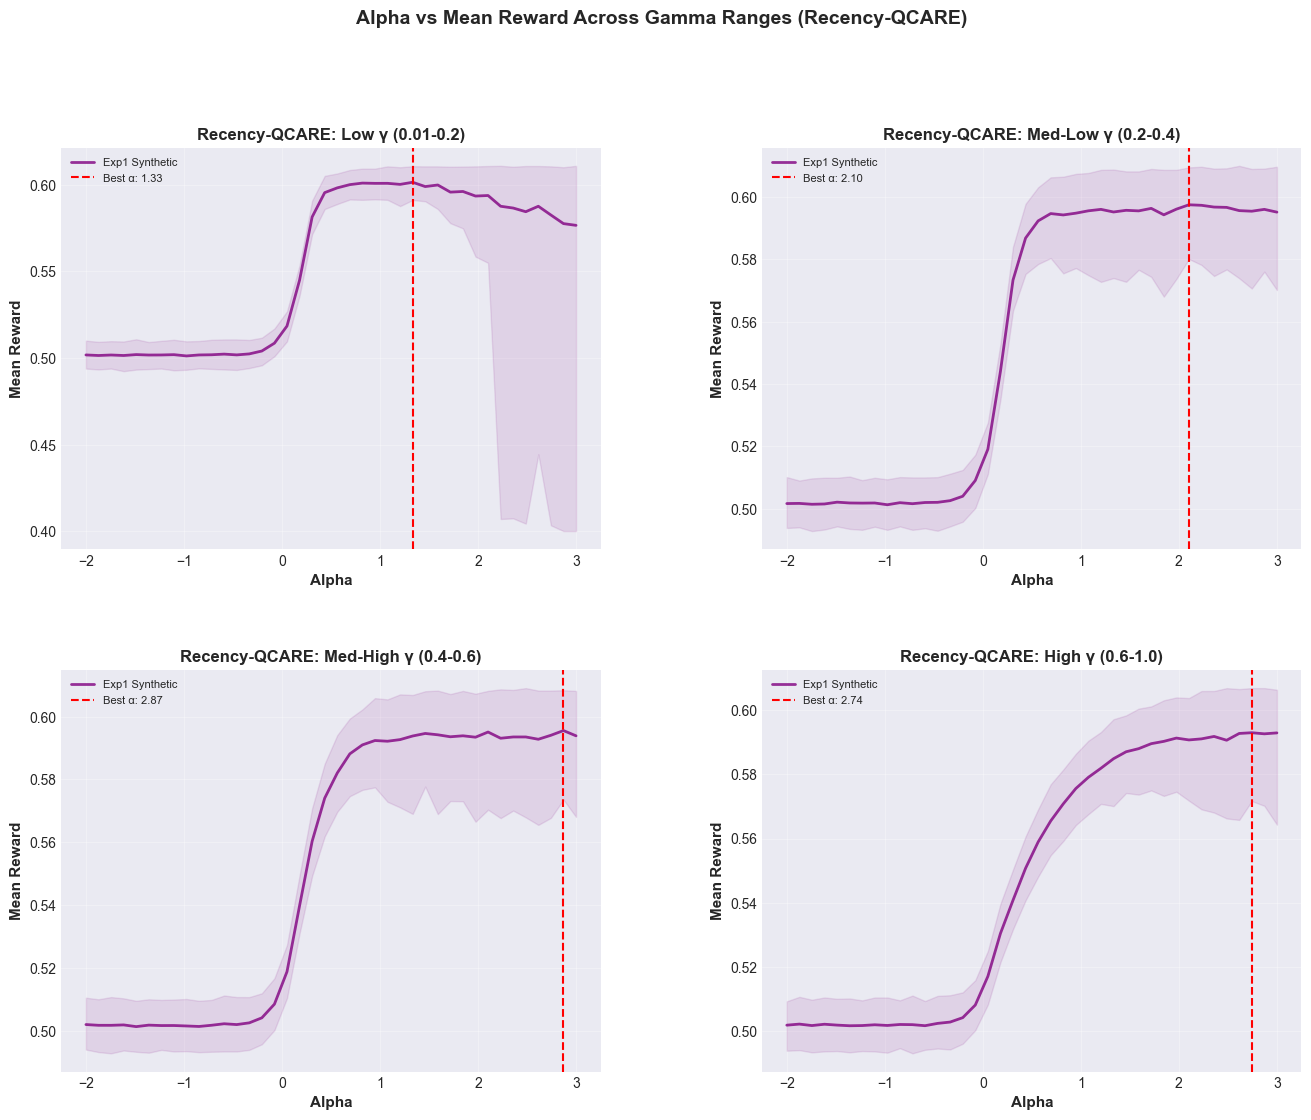

In [74]:
# Create interactive plot with gamma slider (using static slices for each experiment)
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.3)
n_rounds = 10000

# Create subplots for different gamma ranges
gamma_ranges = [(0.01, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.0)]
gamma_labels = ['Low γ (0.01-0.2)', 'Med-Low γ (0.2-0.4)', 'Med-High γ (0.4-0.6)', 'High γ (0.6-1.0)']

print("Generating synthetic curves for gamma ranges...")
for idx, (gamma_min, gamma_max) in enumerate(gamma_ranges):
    ax_idx = idx
    ax = fig.add_subplot(gs[ax_idx // 2, ax_idx % 2])
    
    # Use mean gamma in the range
    gamma_mid = (gamma_min + gamma_max) / 2
    
    # Generate synthetic curves for this gamma
    print(f"Range {gamma_labels[idx]}... (γ_mid={gamma_mid:.3f})")
    syn_rec_exp1_gamma = {}
    
    for alpha in alpha_grid:
        rewards1 = simulate_recency_qcare(n_rounds, alpha, gamma_mid, mu_exp1, num_paths=500)
        syn_rec_exp1_gamma[alpha] = {
            'mean': np.mean(rewards1),
            'p5': np.percentile(rewards1, 5),
            'p95': np.percentile(rewards1, 95)
        }
        
    best_alpha = alpha_grid[np.argmax([syn_rec_exp1_gamma[a]['mean'] for a in alpha_grid])]
    mean_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['mean'] for a in alpha_grid])
    p5_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['p5'] for a in alpha_grid])
    p95_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['p95'] for a in alpha_grid])
    
    # Plot Exp1 synthetic
    ax.plot(alpha_grid, mean_curve_gamma_exp1, color='purple', linewidth=2, linestyle='-', alpha=0.8, label='Exp1 Synthetic')
    ax.fill_between(alpha_grid, p5_curve_gamma_exp1, p95_curve_gamma_exp1, color='purple', alpha=0.1)
    ax.axvline(x=best_alpha, color='red', linestyle='--', linewidth=1.5, label=f'Best α: {best_alpha:.2f}')
    
    ax.set_xlabel('Alpha', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
    ax.set_title(f'Recency-QCARE: {gamma_labels[idx]}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Alpha vs Mean Reward Across Gamma Ranges (Recency-QCARE)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.savefig(os.path.join(script_dir, 'Recency_QCARE_Alpha_by_Gamma_Ranges.png'), dpi=300, bbox_inches='tight')
print("Saved: Recency_QCARE_Alpha_by_Gamma_Ranges.png")
plt.show()

Generating synthetic curves for gamma ranges...
Range Low γ (0.01-0.2)... (γ_mid=0.105)
Range Med-Low γ (0.2-0.4)... (γ_mid=0.300)
Range Med-High γ (0.4-0.6)... (γ_mid=0.500)
Range High γ (0.6-1.0)... (γ_mid=0.800)
Saved: Recency_QCARE_Alpha_by_Gamma_Ranges.png


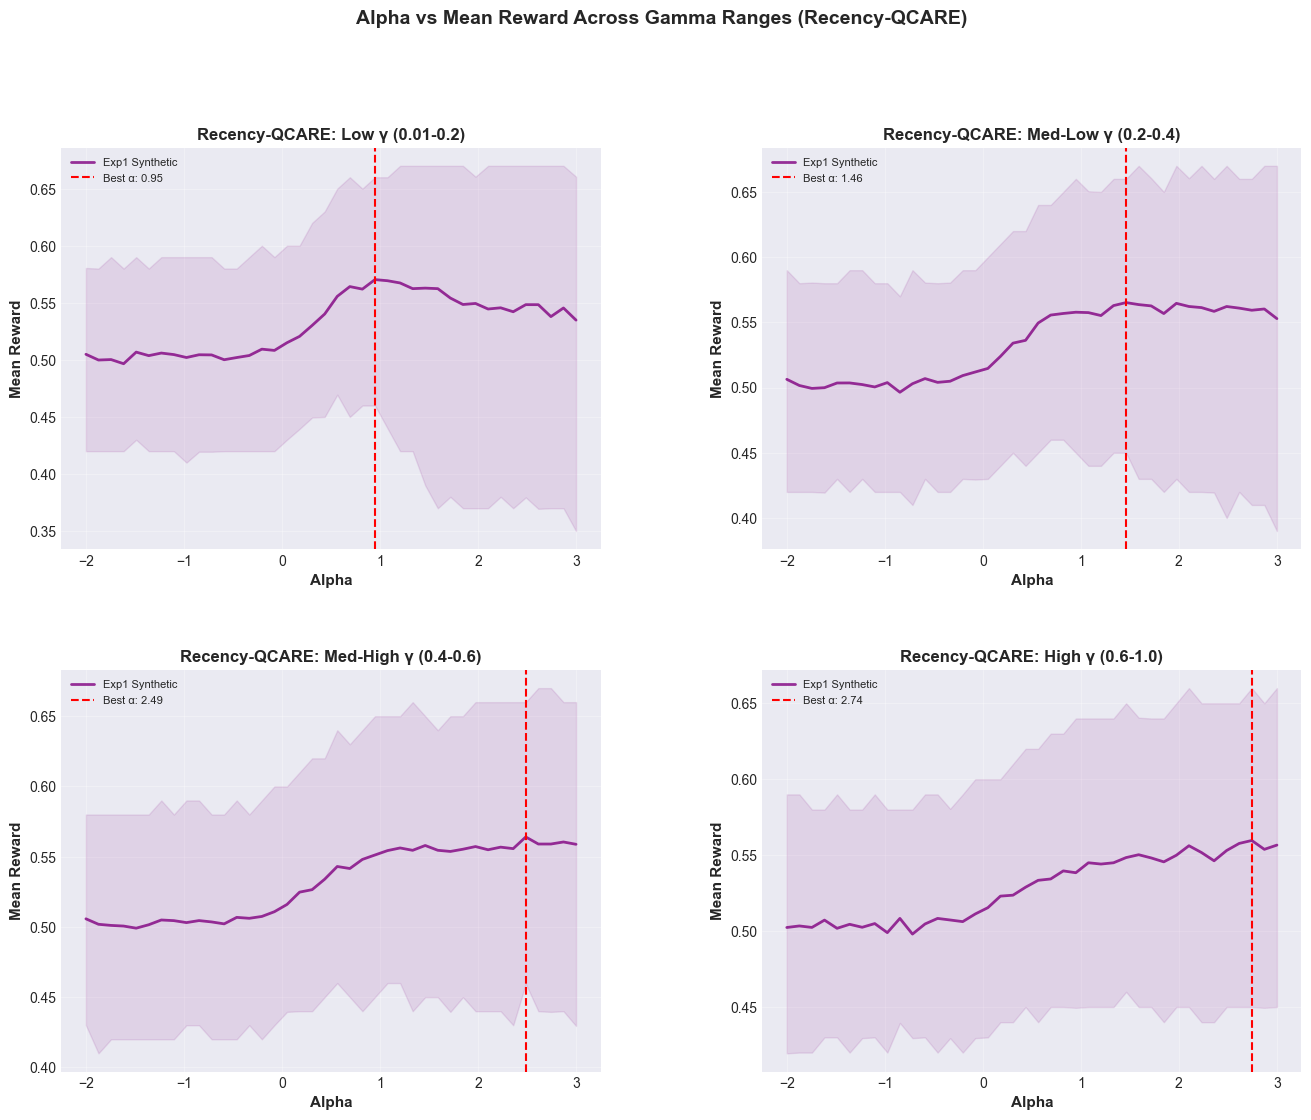

In [75]:
# Create interactive plot with gamma slider (using static slices for each experiment)
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.3)
n_rounds = 100

# Create subplots for different gamma ranges
gamma_ranges = [(0.01, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.0)]
gamma_labels = ['Low γ (0.01-0.2)', 'Med-Low γ (0.2-0.4)', 'Med-High γ (0.4-0.6)', 'High γ (0.6-1.0)']

print("Generating synthetic curves for gamma ranges...")
for idx, (gamma_min, gamma_max) in enumerate(gamma_ranges):
    ax_idx = idx
    ax = fig.add_subplot(gs[ax_idx // 2, ax_idx % 2])
    
    # Use mean gamma in the range
    gamma_mid = (gamma_min + gamma_max) / 2
    
    # Generate synthetic curves for this gamma
    print(f"Range {gamma_labels[idx]}... (γ_mid={gamma_mid:.3f})")
    syn_rec_exp1_gamma = {}
    
    for alpha in alpha_grid:
        rewards1 = simulate_recency_qcare(n_rounds, alpha, gamma_mid, mu_exp1, num_paths=500)
        syn_rec_exp1_gamma[alpha] = {
            'mean': np.mean(rewards1),
            'p5': np.percentile(rewards1, 5),
            'p95': np.percentile(rewards1, 95)
        }
        
    best_alpha = alpha_grid[np.argmax([syn_rec_exp1_gamma[a]['mean'] for a in alpha_grid])]
    mean_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['mean'] for a in alpha_grid])
    p5_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['p5'] for a in alpha_grid])
    p95_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['p95'] for a in alpha_grid])
    
    # Plot Exp1 synthetic
    ax.plot(alpha_grid, mean_curve_gamma_exp1, color='purple', linewidth=2, linestyle='-', alpha=0.8, label='Exp1 Synthetic')
    ax.fill_between(alpha_grid, p5_curve_gamma_exp1, p95_curve_gamma_exp1, color='purple', alpha=0.1)
    ax.axvline(x=best_alpha, color='red', linestyle='--', linewidth=1.5, label=f'Best α: {best_alpha:.2f}')
    
    ax.set_xlabel('Alpha', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
    ax.set_title(f'Recency-QCARE: {gamma_labels[idx]}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Alpha vs Mean Reward Across Gamma Ranges (Recency-QCARE)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.savefig(os.path.join(script_dir, 'Recency_QCARE_Alpha_by_Gamma_Ranges.png'), dpi=300, bbox_inches='tight')
print("Saved: Recency_QCARE_Alpha_by_Gamma_Ranges.png")
plt.show()

## Interactive Visualization: Alpha vs Mean Reward with Gamma Slider

Generating synthetic curves for gamma ranges...
  Range Low γ (0.01-0.2)... (γ_mid=0.105)
  Range Med-Low γ (0.2-0.4)... (γ_mid=0.300)
  Range Med-High γ (0.4-0.6)... (γ_mid=0.500)
  Range High γ (0.6-1.0)... (γ_mid=0.800)
Saved: Recency_QCARE_Alpha_by_Gamma_Ranges.png


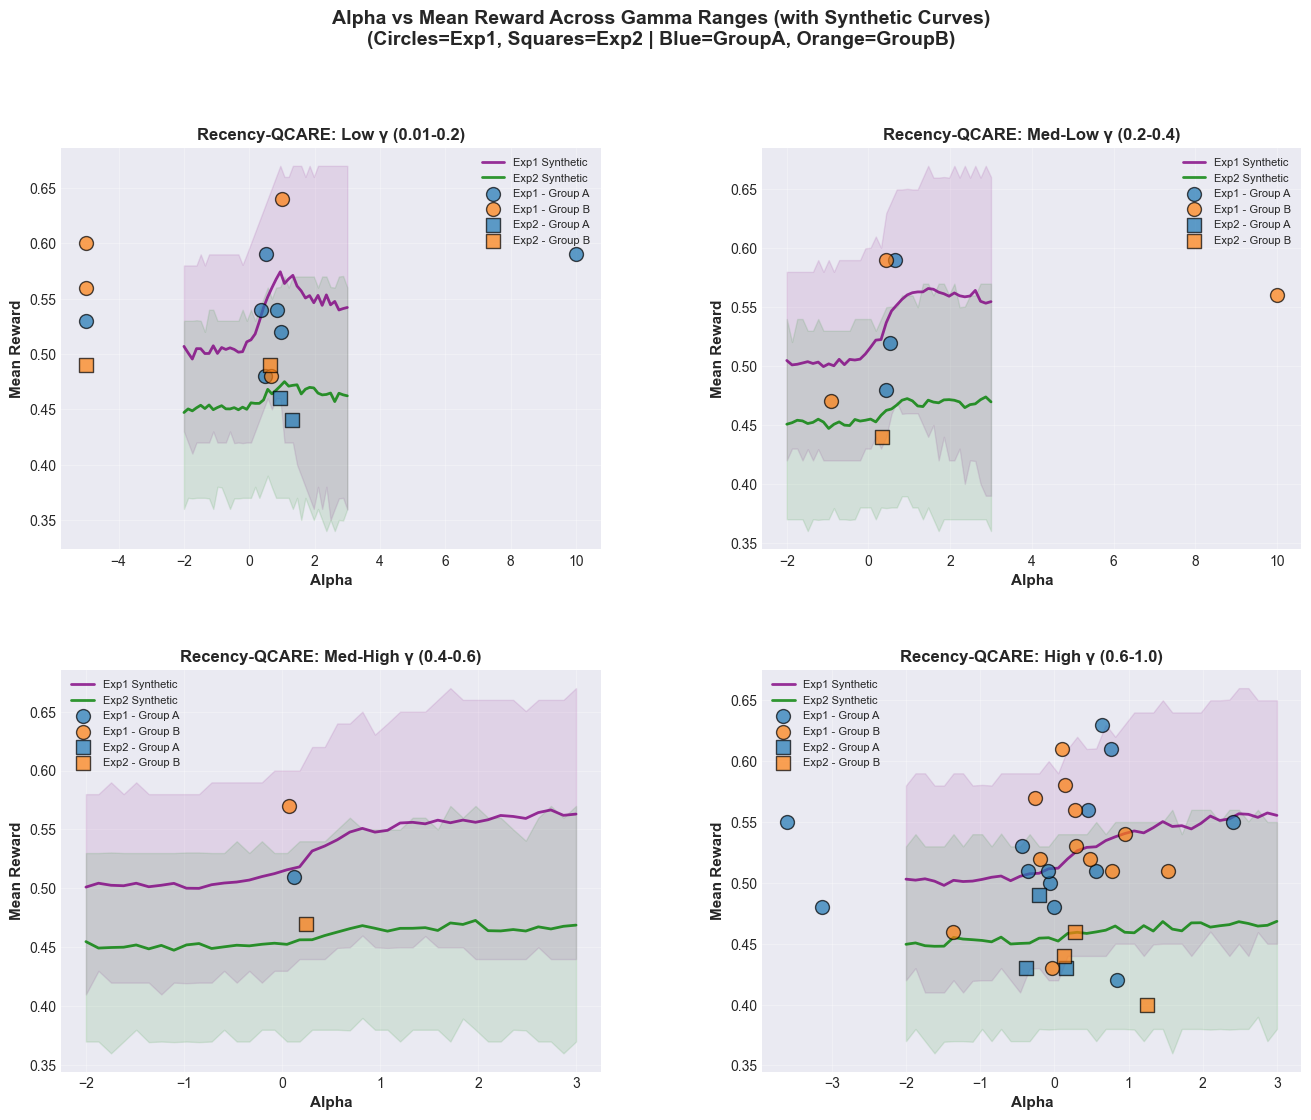

In [69]:
# Create interactive plot with gamma slider (using static slices for each experiment)
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.3)

# Create subplots for different gamma ranges
gamma_ranges = [(0.01, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.0)]
gamma_labels = ['Low γ (0.01-0.2)', 'Med-Low γ (0.2-0.4)', 'Med-High γ (0.4-0.6)', 'High γ (0.6-1.0)']

print("Generating synthetic curves for gamma ranges...")
for idx, (gamma_min, gamma_max) in enumerate(gamma_ranges):
    ax_idx = idx
    ax = fig.add_subplot(gs[ax_idx // 2, ax_idx % 2])
    
    # Use mean gamma in the range
    gamma_mid = (gamma_min + gamma_max) / 2
    
    # Generate synthetic curves for this gamma
    print(f"  Range {gamma_labels[idx]}... (γ_mid={gamma_mid:.3f})")
    syn_rec_exp1_gamma = {}
    syn_rec_exp2_gamma = {}
    
    for alpha in alpha_grid:
        rewards1 = simulate_recency_qcare(n_rounds_exp1, alpha, gamma_mid, mu_exp1, num_paths=500)
        syn_rec_exp1_gamma[alpha] = {
            'mean': np.mean(rewards1),
            'p5': np.percentile(rewards1, 5),
            'p95': np.percentile(rewards1, 95)
        }
        
        rewards2 = simulate_recency_qcare(n_rounds_exp2, alpha, gamma_mid, mu_exp2, num_paths=500)
        syn_rec_exp2_gamma[alpha] = {
            'mean': np.mean(rewards2),
            'p5': np.percentile(rewards2, 5),
            'p95': np.percentile(rewards2, 95)
        }
    
    mean_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['mean'] for a in alpha_grid])
    p5_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['p5'] for a in alpha_grid])
    p95_curve_gamma_exp1 = np.array([syn_rec_exp1_gamma[a]['p95'] for a in alpha_grid])
    
    mean_curve_gamma_exp2 = np.array([syn_rec_exp2_gamma[a]['mean'] for a in alpha_grid])
    p5_curve_gamma_exp2 = np.array([syn_rec_exp2_gamma[a]['p5'] for a in alpha_grid])
    p95_curve_gamma_exp2 = np.array([syn_rec_exp2_gamma[a]['p95'] for a in alpha_grid])
    
    # Plot Exp1 synthetic
    ax.plot(alpha_grid, mean_curve_gamma_exp1, color='purple', linewidth=2, linestyle='-', alpha=0.8, label='Exp1 Synthetic')
    ax.fill_between(alpha_grid, p5_curve_gamma_exp1, p95_curve_gamma_exp1, color='purple', alpha=0.1)
    
    # Plot Exp2 synthetic
    ax.plot(alpha_grid, mean_curve_gamma_exp2, color='green', linewidth=2, linestyle='-', alpha=0.8, label='Exp2 Synthetic')
    ax.fill_between(alpha_grid, p5_curve_gamma_exp2, p95_curve_gamma_exp2, color='green', alpha=0.1)
    
    # Filter for current gamma range
    exp1_filt = recency_exp1[(recency_exp1['gamma'] >= gamma_min) & (recency_exp1['gamma'] < gamma_max)]
    exp2_filt = recency_exp2[(recency_exp2['gamma'] >= gamma_min) & (recency_exp2['gamma'] < gamma_max)]
    
    # Plot Exp1 data
    for grp in ['A', 'B']:
        subset_exp1 = exp1_filt[exp1_filt['ab_group'] == grp]
        ax.scatter(subset_exp1['alpha'], subset_exp1['mean_reward'], 
                  s=100, alpha=0.7, color=colors[grp], marker='o',
                  label=f'Exp1 - Group {grp}', edgecolors='black', linewidth=1, zorder=2)
    
    # Plot Exp2 data
    for grp in ['A', 'B']:
        subset_exp2 = exp2_filt[exp2_filt['ab_group'] == grp]
        ax.scatter(subset_exp2['alpha'], subset_exp2['mean_reward'], 
                  s=100, alpha=0.7, color=colors[grp], marker='s',
                  label=f'Exp2 - Group {grp}', edgecolors='black', linewidth=1, zorder=2)
    
    ax.set_xlabel('Alpha', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
    ax.set_title(f'Recency-QCARE: {gamma_labels[idx]}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Alpha vs Mean Reward Across Gamma Ranges (with Synthetic Curves)\n(Circles=Exp1, Squares=Exp2 | Blue=GroupA, Orange=GroupB)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.savefig(os.path.join(script_dir, 'Recency_QCARE_Alpha_by_Gamma_Ranges.png'), dpi=300, bbox_inches='tight')
print("Saved: Recency_QCARE_Alpha_by_Gamma_Ranges.png")
plt.show()


## Comprehensive Summary Table: QCARE vs Recency-QCARE

In [70]:
print("\n" + "="*100)
print("COMPREHENSIVE SUMMARY: QCARE vs RECENCY-QCARE")
print("="*100)

summary_data = []

# Exp1 Summary
for model, data in [('QCARE', qcare_exp1), ('Recency-QCARE', recency_exp1)]:
    for grp in ['A', 'B']:
        subset = data[data['ab_group'] == grp]
        if len(subset) > 0:
            alpha_mean = subset['alpha'].mean()
            alpha_std = subset['alpha'].std()
            reward_mean = subset['mean_reward'].mean()
            reward_std = subset['mean_reward'].std()
            
            gamma_mean = subset['gamma'].mean() if 'gamma' in subset.columns else np.nan
            gamma_std = subset['gamma'].std() if 'gamma' in subset.columns else np.nan
            
            summary_data.append({
                'Experiment': 'Exp1',
                'Model': model,
                'Group': grp,
                'N': len(subset),
                'Alpha Mean': f"{alpha_mean:.4f}",
                'Alpha Std': f"{alpha_std:.4f}",
                'Gamma Mean': f"{gamma_mean:.4f}" if not np.isnan(gamma_mean) else 'N/A',
                'Reward Mean': f"{reward_mean:.4f}",
                'Reward Std': f"{reward_std:.4f}"
            })

# Exp2 Summary
for model, data in [('QCARE', qcare_exp2), ('Recency-QCARE', recency_exp2)]:
    for grp in ['A', 'B']:
        subset = data[data['ab_group'] == grp]
        if len(subset) > 0:
            alpha_mean = subset['alpha'].mean()
            alpha_std = subset['alpha'].std()
            reward_mean = subset['mean_reward'].mean()
            reward_std = subset['mean_reward'].std()
            
            gamma_mean = subset['gamma'].mean() if 'gamma' in subset.columns else np.nan
            gamma_std = subset['gamma'].std() if 'gamma' in subset.columns else np.nan
            
            summary_data.append({
                'Experiment': 'Exp2',
                'Model': model,
                'Group': grp,
                'N': len(subset),
                'Alpha Mean': f"{alpha_mean:.4f}",
                'Alpha Std': f"{alpha_std:.4f}",
                'Gamma Mean': f"{gamma_mean:.4f}" if not np.isnan(gamma_mean) else 'N/A',
                'Reward Mean': f"{reward_mean:.4f}",
                'Reward Std': f"{reward_std:.4f}"
            })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))
print("\n" + "="*100)


COMPREHENSIVE SUMMARY: QCARE vs RECENCY-QCARE

Experiment         Model Group  N Alpha Mean Alpha Std Gamma Mean Reward Mean Reward Std
      Exp1         QCARE     A 24    -2.4165    2.2855        N/A      0.5304     0.0484
      Exp1         QCARE     B 20    -2.7977    2.7368        N/A      0.5405     0.0539
      Exp1 Recency-QCARE     A 24     0.3291    2.6108     0.5888      0.5304     0.0484
      Exp1 Recency-QCARE     B 20     0.1970    2.8830     0.6099      0.5405     0.0539
      Exp2         QCARE     A  5    -2.6400    2.2857        N/A      0.4500     0.0255
      Exp2         QCARE     B  7    -2.7183    2.4221        N/A      0.4557     0.0321
      Exp2 Recency-QCARE     A  5     0.3610    0.7303     0.5249      0.4500     0.0255
      Exp2 Recency-QCARE     B  7    -0.3027    2.1056     0.5409      0.4557     0.0321



## Alpha Shift Analysis: QCARE → Recency-QCARE

In [71]:
print("\n" + "="*100)
print("ALPHA PARAMETER SHIFT ANALYSIS")
print("="*100)

# Compute shifts
exp1_merged['alpha_shift'] = exp1_merged['alpha_recency'] - exp1_merged['alpha_qcare']
exp2_merged['alpha_shift'] = exp2_merged['alpha_recency'] - exp2_merged['alpha_qcare']

print("\n--- EXPERIMENT 1 ---")
print(f"Overall Alpha Shift (Recency - QCARE):")
print(f"  Mean: {exp1_merged['alpha_shift'].mean():.4f}")
print(f"  Std:  {exp1_merged['alpha_shift'].std():.4f}")
print(f"  Min:  {exp1_merged['alpha_shift'].min():.4f}")
print(f"  Max:  {exp1_merged['alpha_shift'].max():.4f}")

print("\nBy Group:")
for grp in ['A', 'B']:
    subset = exp1_merged[exp1_merged['ab_group'] == grp]
    print(f"\n  Group {grp}:")
    print(f"    Mean Shift: {subset['alpha_shift'].mean():.4f}")
    print(f"    Std Shift:  {subset['alpha_shift'].std():.4f}")
    print(f"    Mean Gamma: {subset['gamma'].mean():.4f}")

print("\n--- EXPERIMENT 2 ---")
print(f"Overall Alpha Shift (Recency - QCARE):")
print(f"  Mean: {exp2_merged['alpha_shift'].mean():.4f}")
print(f"  Std:  {exp2_merged['alpha_shift'].std():.4f}")
print(f"  Min:  {exp2_merged['alpha_shift'].min():.4f}")
print(f"  Max:  {exp2_merged['alpha_shift'].max():.4f}")

print("\nBy Group:")
for grp in ['A', 'B']:
    subset = exp2_merged[exp2_merged['ab_group'] == grp]
    print(f"\n  Group {grp}:")
    print(f"    Mean Shift: {subset['alpha_shift'].mean():.4f}")
    print(f"    Std Shift:  {subset['alpha_shift'].std():.4f}")
    print(f"    Mean Gamma: {subset['gamma'].mean():.4f}")

print("\n" + "="*100)


ALPHA PARAMETER SHIFT ANALYSIS

--- EXPERIMENT 1 ---
Overall Alpha Shift (Recency - QCARE):
  Mean: 2.8588
  Std:  2.2613
  Min:  -3.5198
  Max:  5.7295

By Group:

  Group A:
    Mean Shift: 2.7456
    Std Shift:  2.3020
    Mean Gamma: 0.5888

  Group B:
    Mean Shift: 2.9946
    Std Shift:  2.2633
    Mean Gamma: 0.6099

--- EXPERIMENT 2 ---
Overall Alpha Shift (Recency - QCARE):
  Mean: 2.6595
  Std:  3.1331
  Min:  -3.5057
  Max:  6.2501

By Group:

  Group A:
    Mean Shift: 3.0010
    Std Shift:  2.4917
    Mean Gamma: 0.5249

  Group B:
    Mean Shift: 2.4157
    Std Shift:  3.7002
    Mean Gamma: 0.5409



## Analysis Complete!

### Generated Visualizations:
1. **QCARE_Alpha_vs_Reward_Both_Exp.png** - QCARE model with synthetic curves for both experiments
2. **Recency_QCARE_4Panel_Both_Exp.png** - 4-panel plot showing Alpha & Gamma relationships for both experiments
3. **Alpha_Shift_Exp1_By_Group.png** - Parameter shift visualization separated by group for Experiment 1
4. **Alpha_Shift_Exp2_By_Group.png** - Parameter shift visualization separated by group for Experiment 2
5. **Recency_QCARE_Alpha_by_Gamma_Ranges.png** - Interactive gamma range visualization

### Key Outputs:
- Parameter estimates (α, γ) per participant per experiment
- Train/Test log-likelihood statistics for model validation
- Overfitting analysis comparing both models
- Detailed group-wise comparisons
- Alpha shift magnitude and direction analysis